In [ ]:
from __future__ import annotations

import json
import os
import glob
import traceback
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np

# Ensure non-interactive backend (no display)
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402

from pynwb import NWBHDF5IO  # noqa: E402
from aind_dynamic_foraging_models.generative_model import ForagerCollection  # noqa: E402


# -----------------------------
# User config
# -----------------------------
# Now supports multiple folders
LOCAL_NWB_ROOTS: List[str] = [
    "/root/capsule/data/behavior_nwb",
    "/data/foraging_nwb_bonsai",
    # "/data/other_folder",
]

RESULTS_ROOT = Path("/root/capsule/scratch/model_comparison")
MIN_VALID_TRIALS = 10

# Differential evolution config
DE_KWARGS = dict(
    workers=4,
    disp=False,
    seed=np.random.default_rng(42),
)

# If True, save fitted-session plots (still not displayed)
SAVE_FIGS = False
FIG_DPI = 150

# Parallelism across sessions
MAX_WORKERS = max(1, (os.cpu_count() or 2) // 2)


# -----------------------------
# NWB helpers
# -----------------------------
def get_nwb_from_path(nwb_path: str):
    """Open NWB file from a full path."""
    io = NWBHDF5IO(nwb_path, mode="r")
    nwb = io.read()
    return io, nwb


def get_history_from_nwb(nwb) -> Tuple[bool, np.ndarray, np.ndarray, np.ndarray]:
    """
    Get choice and reward history from NWB file.

    Returns
    -------
    baiting : bool
    choice_history : np.ndarray of shape (n_trials,), values in {0,1} (NaNs removed later)
    reward_history : np.ndarray of shape (n_trials,), dtype bool/int
    autowater_offered : np.ndarray of shape (n_trials,), dtype bool
    """
    df_trial = nwb.trials.to_dataframe()

    autowater_offered = (df_trial.auto_waterL == 1) | (df_trial.auto_waterR == 1)
    choice_history = df_trial.animal_response.map({0: 0, 1: 1, 2: np.nan}).values

    # Keep reward_history consistent with your original logic:
    reward_history = (df_trial.rewarded_historyL | df_trial.rewarded_historyR).to_numpy()

    baiting = False if "without baiting" in (nwb.protocol or "").lower() else True

    return baiting, choice_history, reward_history, autowater_offered.to_numpy()


def get_auto_train_stage_last(nwb) -> Any:
    """
    Extract the last auto_train_stage value from NWB trials, if present.
    Returns None if missing or any error occurs.
    """
    try:
        if hasattr(nwb, "trials") and "auto_train_stage" in nwb.trials.colnames:
            col = nwb.trials["auto_train_stage"].data[:]
            if len(col) > 0:
                return col[-1]
    except Exception:
        return None
    return None


# -----------------------------
# Forager specs (edit this list to add models)
# -----------------------------
@dataclass(frozen=True)
class ForagerSpec:
    """Specification for a forager model to fit."""

    name: str
    preset: Optional[str] = None
    agent_class_name: Optional[str] = None
    agent_kwargs: Optional[Dict[str, Any]] = None
    clamp_params: Optional[Dict[str, Any]] = None


def build_forager(spec: ForagerSpec):
    """Instantiate a forager from a preset or class_name + kwargs."""
    fc = ForagerCollection()
    if spec.preset is not None:
        return fc.get_preset_forager(spec.preset)
    if spec.agent_class_name is not None:
        return fc.get_forager(
            agent_class_name=spec.agent_class_name,
            agent_kwargs=spec.agent_kwargs or {},
        )
    raise ValueError(f"Invalid ForagerSpec: {spec}")


# Adjusted agent kwargs to match expected parameters for ForagerCompareThreshold
FORAGERS: List[ForagerSpec] = [
    ForagerSpec(
        name="ForagingCompareThreshold_L1",
        agent_class_name="ForagerCompareThreshold",
        agent_kwargs={"number_of_learning_rate": 1, "reset_to_threshold": True},
    ),
    ForagerSpec(
        name="ForagingCompareThreshold_L1_NoReset",
        agent_class_name="ForagerCompareThreshold",
        agent_kwargs={"number_of_learning_rate": 1, "reset_to_threshold": False},
    ),
    ForagerSpec(
        name="ForagingCompareThreshold_L2",
        agent_class_name="ForagerCompareThreshold",
        agent_kwargs={"number_of_learning_rate": 2, "reset_to_threshold": True},
    ),
    ForagerSpec(
        name="ForagingCompareThreshold_L2_NoReset",
        agent_class_name="ForagerCompareThreshold",
        agent_kwargs={"number_of_learning_rate": 2, "reset_to_threshold": False},
    ),
    # Adding the preset models Hattori2019 and Bari2019
    ForagerSpec(name="Hattori2019", preset="Hattori2019"),
    ForagerSpec(name="Bari2019", preset="Bari2019"),
]


# -----------------------------
# Serialization helpers
# -----------------------------
def _to_jsonable(x: Any) -> Any:
    """Best-effort conversion to JSON-serializable types."""
    if isinstance(x, (str, int, float, bool)) or x is None:
        return x
    if isinstance(x, (list, tuple)):
        return [_to_jsonable(v) for v in x]
    if isinstance(x, dict):
        return {str(k): _to_jsonable(v) for k, v in x.items()}
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (np.integer, np.floating, np.bool_)):
        return x.item()
    return str(x)


def save_json(path: Path, payload: Dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w") as f:
        json.dump(_to_jsonable(payload), f, indent=2)


def dump_fitted_agent(model_folder: Path, forager: Any) -> Dict[str, Any]:
    """
    Save the entire fitted agent.
    - First try stdlib pickle
    - Then fall back to cloudpickle
    - Then fall back to joblib

    Returns a dict of fields to merge into model_out.
    """
    model_folder.mkdir(parents=True, exist_ok=True)

    # Attempt 1: pickle
    try:
        import pickle

        p = model_folder / "fitted_agent.pkl"
        with p.open("wb") as f:
            pickle.dump(forager, f, protocol=pickle.HIGHEST_PROTOCOL)
        return {"pickle_saved": True, "pickle_backend": "pickle", "pickle_file": p.name}
    except Exception as e1:
        err1 = f"{type(e1).__name__}: {e1}"

    # Attempt 2: cloudpickle
    try:
        import cloudpickle  # type: ignore

        p = model_folder / "fitted_agent.cloudpickle"
        with p.open("wb") as f:
            cloudpickle.dump(forager, f)
        return {
            "pickle_saved": True,
            "pickle_backend": "cloudpickle",
            "pickle_file": p.name,
            "pickle_fallback_error": err1,
        }
    except Exception as e2:
        err2 = f"{type(e2).__name__}: {e2}"

    # Attempt 3: joblib
    try:
        import joblib  # type: ignore

        p = model_folder / "fitted_agent.joblib"
        joblib.dump(forager, p, compress=3)
        return {
            "pickle_saved": True,
            "pickle_backend": "joblib",
            "pickle_file": p.name,
            "pickle_fallback_error": err1,
            "pickle_cloudpickle_error": err2,
        }
    except Exception as e3:
        err3 = f"{type(e3).__name__}: {e3}"

    return {
        "pickle_saved": False,
        "pickle_error": err1,
        "cloudpickle_error": err2,
        "joblib_error": err3,
    }


# -----------------------------
# Core fit routine (per session)
# -----------------------------
def fit_one_session(session_path: str) -> Dict[str, Any]:
    """
    Fit all FORAGERS for a single NWB session.
    Saves outputs under RESULTS_ROOT/<session_id>/.
    Returns a lightweight summary dict for aggregation.
    """
    session_id = Path(session_path).stem
    out_dir = RESULTS_ROOT / session_id
    out_dir.mkdir(parents=True, exist_ok=True)

    session_summary: Dict[str, Any] = {
        "session_id": session_id,
        "nwb_path": session_path,
        "status": "ok",
        "n_valid_trials": None,
        "models": {},
    }

    io = None
    try:
        io, nwb = get_nwb_from_path(session_path)

        baiting, choice_history, reward_history, autowater_offered = get_history_from_nwb(nwb)

        # ----------------------------------------
        # Extract auto_train_stage (if exists)
        # ----------------------------------------
        auto_train_stage_last = get_auto_train_stage_last(nwb)
        session_summary["auto_train_stage"] = (
            None if auto_train_stage_last is None else _to_jsonable(auto_train_stage_last)
        )

        # Remove NaN choices
        ignored = np.isnan(choice_history)
        choice_valid = choice_history[~ignored].astype(int)
        reward_valid = reward_history[~ignored].astype(int)

        session_summary["n_valid_trials"] = int(len(choice_valid))
        session_summary["baiting"] = bool(baiting)

        if len(choice_valid) < MIN_VALID_TRIALS:
            session_summary["status"] = f"skipped: valid trials < {MIN_VALID_TRIALS}"
            save_json(out_dir / "summary.json", session_summary)
            return session_summary

        # Fit each model
        for spec in FORAGERS:
            model_key = spec.name
            model_out: Dict[str, Any] = {"status": "ok"}

            # Include stage info in every model output
            model_out["auto_train_stage"] = session_summary.get("auto_train_stage", None)

            try:
                forager = build_forager(spec)

                fitting_result, _ = forager.fit(
                    choice_valid,
                    reward_valid,
                    clamp_params=spec.clamp_params or {},
                    DE_kwargs=DE_KWARGS,
                    # k_fold_cross_validation=None
                )

                # Create a dedicated folder for each model fitting
                model_folder = out_dir / model_key
                model_folder.mkdir(parents=True, exist_ok=True)

                # Save the entire fitted agent (robust fallbacks)
                model_out.update(dump_fitted_agent(model_folder, forager))

                # Pull key numbers safely
                fit_settings = getattr(fitting_result, "fit_settings", {}) or {}
                fit_names = fit_settings.get("fit_names", None)

                model_out.update(
                    dict(
                        n_trials=int(len(choice_valid)),
                        LPT=float(getattr(fitting_result, "LPT", np.nan)),
                        AIC=float(getattr(fitting_result, "AIC", np.nan)),
                        BIC=float(getattr(fitting_result, "BIC", np.nan)),
                        prediction_accuracy=float(
                            getattr(fitting_result, "prediction_accuracy", np.nan)
                        ),
                        fit_names=fit_names,
                        x=[float(v) for v in list(getattr(fitting_result, "x", []))],
                    )
                )

                # Save a JSON version (includes auto_train_stage now)
                save_json(model_folder / f"{model_key}.json", model_out)

                # Optional figure saving (no display)
                if SAVE_FIGS:
                    try:
                        fig, _axes = forager.plot_fitted_session(if_plot_latent=True)
                        fig.savefig(model_folder / f"{model_key}.png", dpi=FIG_DPI)
                        plt.close(fig)
                        model_out["fig_saved"] = True
                    except Exception as e:
                        model_out["fig_saved"] = False
                        model_out["fig_error"] = f"{type(e).__name__}: {e}"

            except Exception as e:
                model_out["status"] = "error"
                model_out["error"] = f"{type(e).__name__}: {e}"
                model_out["traceback"] = traceback.format_exc()

                # Still write JSON so you can see failures per model
                save_json(out_dir / f"{model_key}.json", model_out)

            session_summary["models"][model_key] = model_out

        # Save per-session rollup
        save_json(out_dir / "summary.json", session_summary)
        return session_summary

    except Exception as e:
        session_summary["status"] = "error"
        session_summary["error"] = f"{type(e).__name__}: {e}"
        session_summary["traceback"] = traceback.format_exc()
        save_json(out_dir / "summary.json", session_summary)
        return session_summary

    finally:
        try:
            if io is not None:
                io.close()
        except Exception:
            pass


# -----------------------------
# Batch runner (parallel by session)
# -----------------------------
def find_all_sessions(local_roots: List[str]) -> List[str]:
    """Return all .nwb file paths across all roots (deduplicated)."""
    all_paths: List[str] = []
    for root in local_roots:
        all_paths.extend(glob.glob(f"{root}/*.nwb"))
    return sorted(list(set(all_paths)))


def main() -> None:
    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

    session_paths = find_all_sessions(LOCAL_NWB_ROOTS)
    if len(session_paths) == 0:
        raise RuntimeError(f"No .nwb files found under: {LOCAL_NWB_ROOTS}")

    # Parallel across sessions
    from concurrent.futures import ProcessPoolExecutor, as_completed

    all_summaries: List[Dict[str, Any]] = []
    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = {ex.submit(fit_one_session, p): p for p in session_paths}
        for fut in as_completed(futures):
            all_summaries.append(fut.result())

    # Save global summary (one file)
    global_summary = {
        "local_roots": LOCAL_NWB_ROOTS,
        "results_root": str(RESULTS_ROOT),
        "n_sessions_found": int(len(session_paths)),
        "n_sessions_processed": int(len(all_summaries)),
        "foragers": [spec.__dict__ for spec in FORAGERS],
        "summaries": all_summaries,
    }
    save_json(RESULTS_ROOT / "ALL_SESSIONS_SUMMARY.json", global_summary)


if __name__ == "__main__":
    main()

2026-02-23 19:26:38,109 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...


In [1]:
import cloudpickle
from pathlib import Path

path = Path("/root/capsule/scratch/model_comparison/684039_2023-11-14_09-44-22/Hattori2019/fitted_agent.cloudpickle")

with path.open("rb") as f:
    fitted_agent = cloudpickle.load(f)

print(type(fitted_agent))

<class 'aind_dynamic_foraging_models.generative_model.forager_q_learning.ForagerQLearning'>


In [36]:
fitted_agent.get_fitting_result_dict().keys()

dict_keys(['fit_settings', 'params', 'log_likelihood', 'AIC', 'BIC', 'LPT', 'LPT_AIC', 'LPT_BIC', 'k_model', 'n_trials', 'nfev', 'nit', 'success', 'population', 'population_energies', 'params_without_polishing', 'log_likelihood_without_polishing', 'prediction_accuracy', 'fitted_latent_variables'])

In [24]:
fitted_agent.get_latent_variables().keys()

dict_keys(['q_value', 'choice_kernel', 'choice_prob'])

In [37]:
fitted_agent.get_fitting_result_dict()['fit_settings']['fit_choice_history']

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1]

In [31]:
len(fitted_agent.get_fitting_result_dict()['fitted_latent_variables']['choice_prob'][0])

183

In [3]:
dir(fitted_agent)

['ParamFitBoundModel',
 'ParamModel',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_cost_func_for_DE',
 '_fitting_result_to_dict',
 '_get_params_list',
 '_get_params_model',
 '_optimize_DE',
 '_reset',
 'act',
 'agent_kwargs',
 'choice_history',
 'choice_kernel',
 'choice_prob',
 'fit',
 'fit_choice_kernel',
 'fitting_result',
 'fitting_result_cross_validation',
 'get_agent_alias',
 'get_choice_history',
 'get_fitting_result_dict',
 'get_latent_variables',
 'get_p_reward',
 'get_params',
 'get_params_str',
 'get_reward_history',
 'learn',
 'load',
 'n_actions',
 'n_trials',
 'params',
 'params_list_all',
 'params_list_free',
 'params_list_frozen',
 'perform',
 'per

learn_rate_rew=0.8263721703506691 learn_rate_unrew=0.2998855214906069 forget_rate_unchosen=0.1927392692467882 biasL=-0.7598385124144968 softmax_inverse_temperature=61.65817399203861


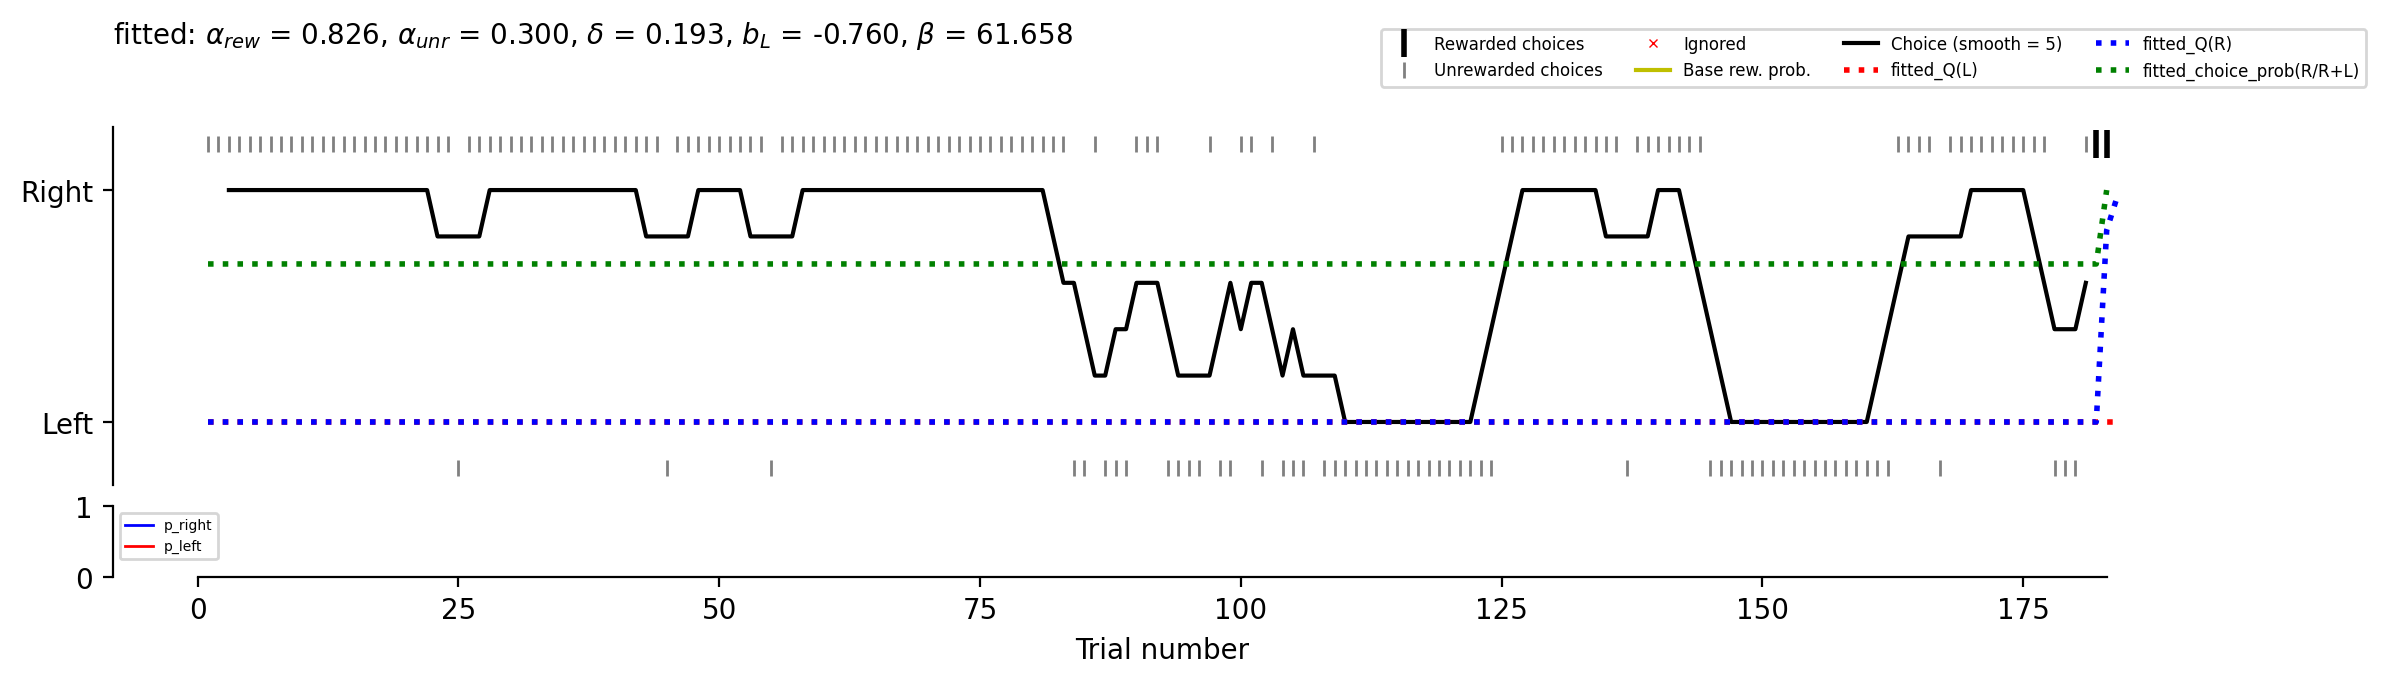

In [12]:
# Access fitted parameters
print(fitted_agent.params)

# Plot session (if supported)
fig, _ = fitted_agent.plot_fitted_session(if_plot_latent=True)
fig.show()


Summary statistics for stage: STAGE_FINAL

Metric: AIC
  Bari2019                            | n=2055 | mean=234.650760 | median=224.311713
  ForagingCompareThreshold_L1         | n=2055 | mean=235.187147 | median=225.039762
  ForagingCompareThreshold_L1_NoReset | n=2055 | mean=245.965035 | median=237.397112
  ForagingCompareThreshold_L2         | n=2055 | mean=235.491019 | median=225.951573
  ForagingCompareThreshold_L2_NoReset | n=2055 | mean=246.106872 | median=237.361034
  Hattori2019                         | n=2055 | mean=236.677040 | median=227.302290
--------------------------------------------------------------------------------
Metric: BIC
  Bari2019                            | n=2055 | mean=254.060518 | median=244.393655
  ForagingCompareThreshold_L1         | n=2055 | mean=250.714953 | median=241.076858
  ForagingCompareThreshold_L1_NoReset | n=2055 | mean=261.492841 | median=253.093516
  ForagingCompareThreshold_L2         | n=2055 | mean=254.900777 | median=245.808543
 

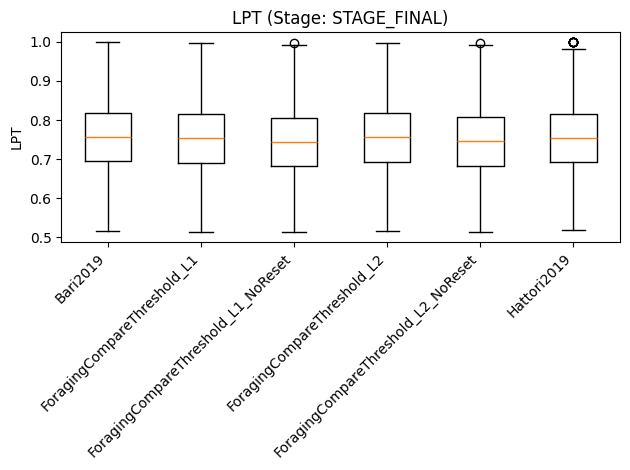

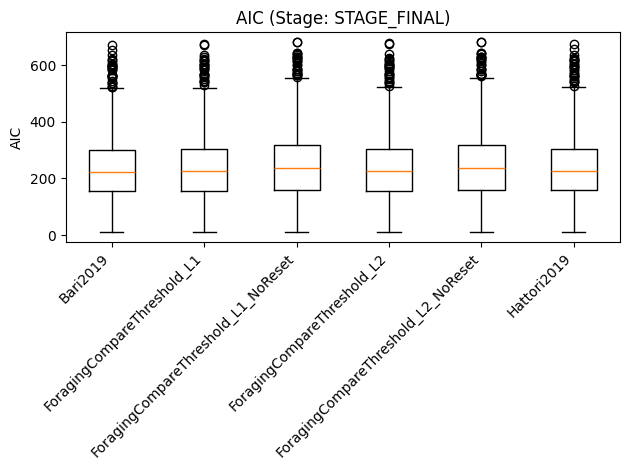

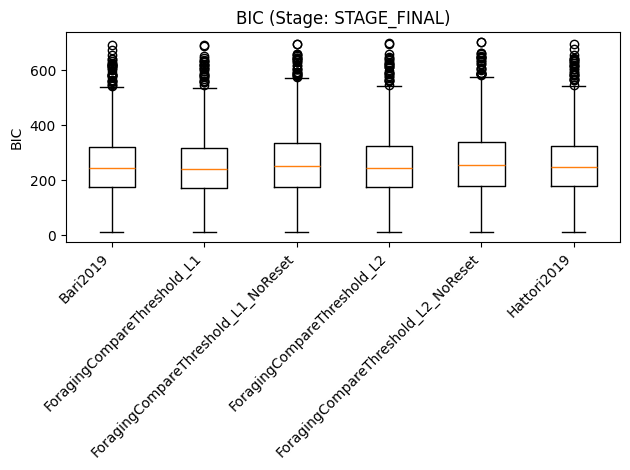

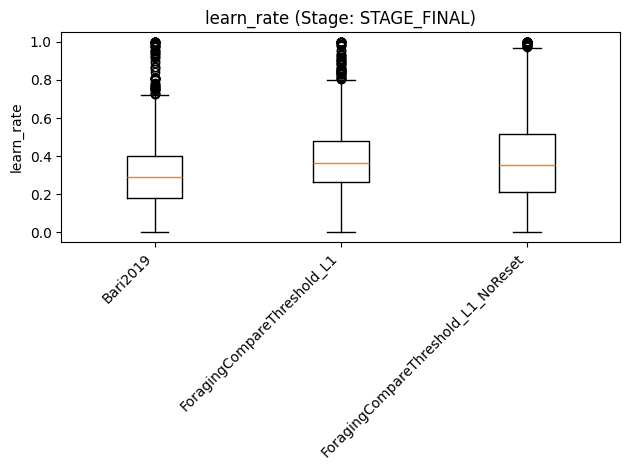

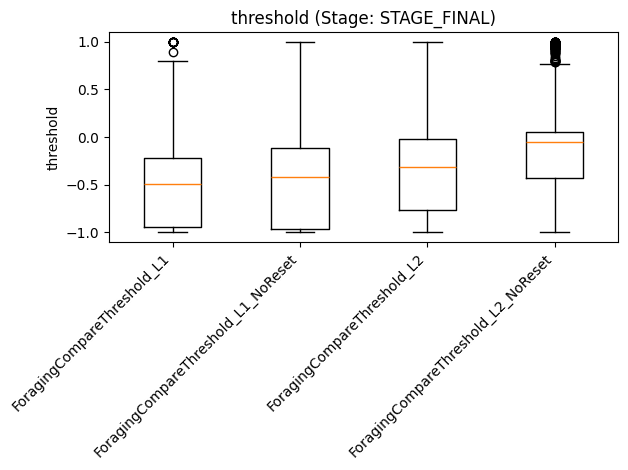

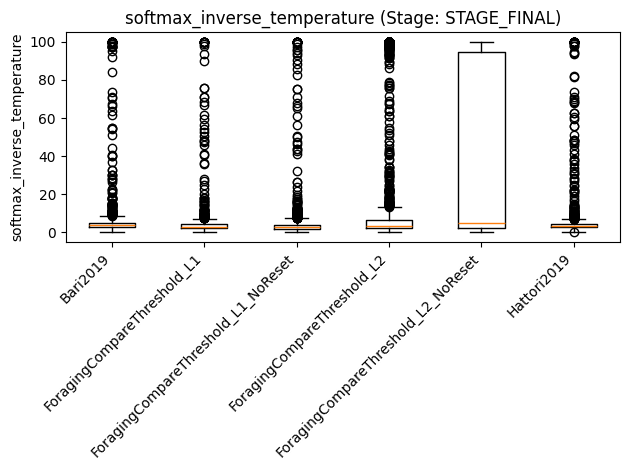

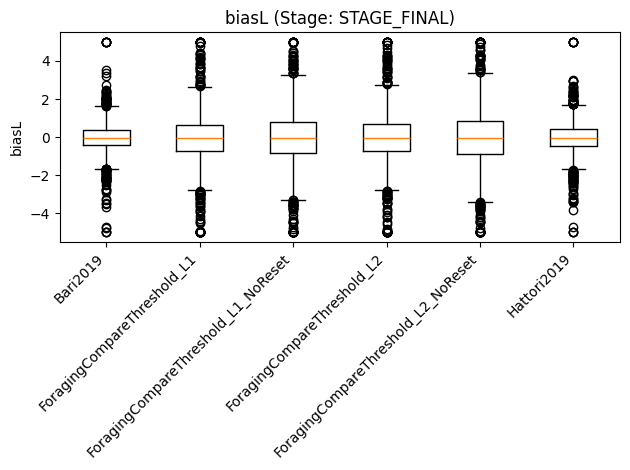

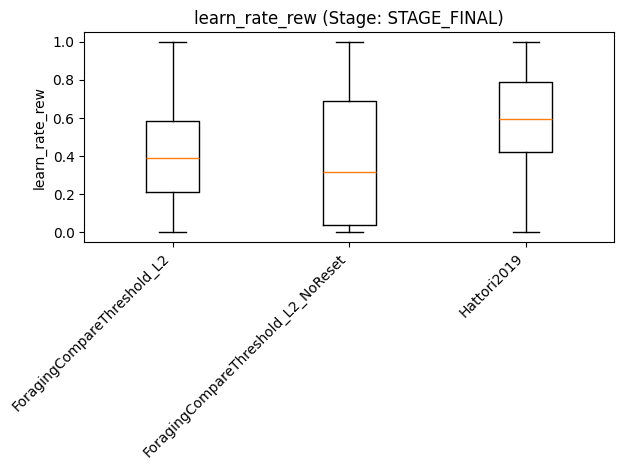

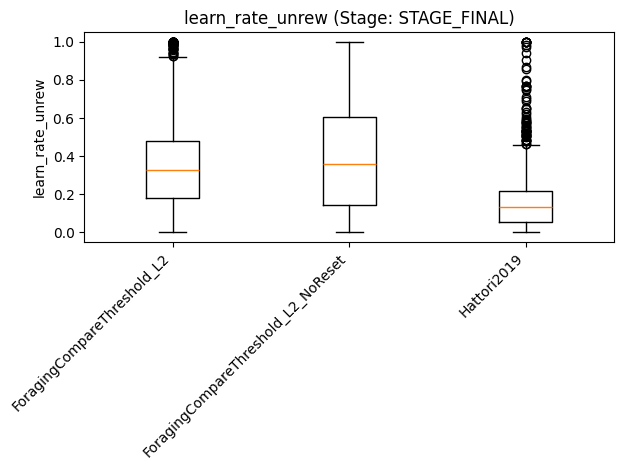

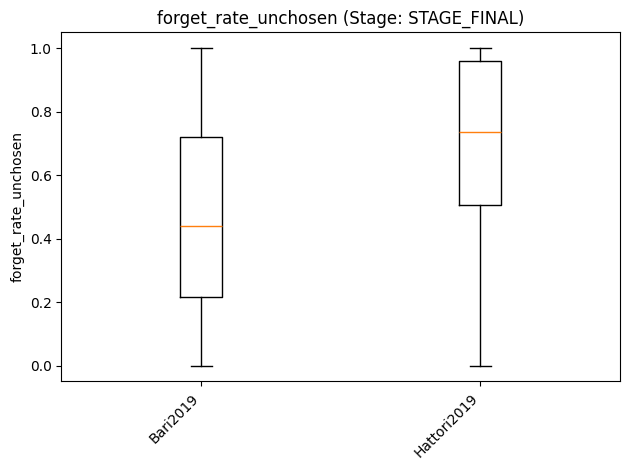

In [2]:
# This script loads all summary.json files under the given root directory,
# filters by a specific auto_train_stage (e.g., "STAGE_FINAL"),
# generates separate box plots (one per figure) for selected metrics
# across different models,
# AND prints the average and median values per model per metric.

import json
import glob
import os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT_DIR = "/root/capsule/scratch/model_comparison"
TARGET_STAGE = "STAGE_FINAL"

# Metrics to extract (model-level)
MODEL_METRICS = [
    "LPT",
    "AIC",
    "BIC",
]

# Parameter names that may appear inside fit_names
PARAM_NAMES = [
    "learn_rate",
    "threshold",
    "softmax_inverse_temperature",
    "biasL",
    "learn_rate_rew",
    "learn_rate_unrew",
    "forget_rate_unchosen",
]

ALL_METRICS = MODEL_METRICS + PARAM_NAMES

# ---------------------------------------------------------------------
# Step 1: Collect data across all sessions
# ---------------------------------------------------------------------

# Structure: metric_data[metric][model_name] = list of values
metric_data = defaultdict(lambda: defaultdict(list))

summary_paths = glob.glob(os.path.join(ROOT_DIR, "*", "summary.json"))

for summary_path in summary_paths:
    try:
        with open(summary_path, "r") as f:
            summary = json.load(f)
    except Exception:
        continue

    # Filter by session-level auto_train_stage
    if summary.get("auto_train_stage") != TARGET_STAGE:
        continue

    models = summary.get("models", {})
    for model_name, model_info in models.items():
        if model_info.get("status") != "ok":
            continue

        # --- Standard metrics ---
        for metric in MODEL_METRICS:
            if metric in model_info:
                metric_data[metric][model_name].append(model_info[metric])

        # --- Parameter extraction ---
        fit_names = model_info.get("fit_names", [])
        x_values = model_info.get("x", [])

        for param_name in PARAM_NAMES:
            if param_name in fit_names:
                idx = fit_names.index(param_name)
                if idx < len(x_values):
                    metric_data[param_name][model_name].append(x_values[idx])

# ---------------------------------------------------------------------
# Step 2: Print summary statistics
# ---------------------------------------------------------------------

print(f"\nSummary statistics for stage: {TARGET_STAGE}\n")

for metric_name in sorted(metric_data.keys()):
    print(f"Metric: {metric_name}")
    for model_name, values in sorted(metric_data[metric_name].items()):
        if len(values) == 0:
            continue
        arr = np.array(values, dtype=float)
        mean_val = np.mean(arr)
        median_val = np.median(arr)
        print(
            f"  {model_name:35s} | "
            f"n={len(arr):3d} | "
            f"mean={mean_val:.6f} | "
            f"median={median_val:.6f}"
        )
    print("-" * 80)

# ---------------------------------------------------------------------
# Step 3: Generate box plots (one figure per metric)
# ---------------------------------------------------------------------

def plot_boxplot_for_metric(metric_name, data_dict):
    models = sorted(data_dict.keys())
    data = [data_dict[m] for m in models]

    # Remove empty lists
    filtered = [(m, d) for m, d in zip(models, data) if len(d) > 0]
    if len(filtered) == 0:
        return

    models, data = zip(*filtered)

    plt.figure()
    plt.boxplot(data)
    plt.xticks(range(1, len(models) + 1), models, rotation=45, ha="right")
    plt.title(f"{metric_name} (Stage: {TARGET_STAGE})")
    plt.ylabel(metric_name)
    plt.tight_layout()
    plt.show()


# Plot all collected metrics
for metric_name, data_dict in metric_data.items():
    plot_boxplot_for_metric(metric_name, data_dict)


In [38]:
"""
Compute per-trial log-likelihood from fitted agents, then summarize switch-trial
and post-switch-trial log-likelihood across all sessions/models whose
auto_train_stage == "STAGE_FINAL" (read from each model JSON).

Folder structure:
  ROOT/
    <session_id>/
      <model_name>/
        fitted_agent.cloudpickle
        <model_name>.json   (or any .json summary)

Outputs (written under ROOT):
  - switch_loglik_per_event.csv   (one row per switch event)
  - switch_loglik_summary.csv     (aggregated per session/model)
  - switch_loglik_summary_by_model.csv (aggregated across sessions per model)
"""

from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

import cloudpickle


# -----------------------------
# User config
# -----------------------------
ROOT = Path("/root/capsule/scratch/model_comparison")
REQUIRE_STAGE = "STAGE_FINAL"
N_AFTER = 10  # "n trials after the switch trial" -> change this as you like
EPS = 1e-12   # probability clipping to avoid log(0)


# -----------------------------
# Helpers
# -----------------------------
def _safe_read_json(path: Path) -> Optional[Dict]:
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None


def _find_model_json(model_dir: Path, model_name: str) -> Optional[Path]:
    preferred = model_dir / f"{model_name}.json"
    if preferred.exists():
        return preferred

    # fallback: any json in that folder
    candidates = sorted(model_dir.glob("*.json"))
    return candidates[0] if candidates else None


def _load_fitted_agent(pkl_path: Path):
    with pkl_path.open("rb") as f:
        return cloudpickle.load(f)


def _extract_fit_choice_history_and_p_left(fitted_agent) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      choices: shape (T,), values {0,1}
      p_left:  shape (T,), left choice probability for each trial
    """
    res = fitted_agent.get_fitting_result_dict()

    choices = np.asarray(res["fit_settings"]["fit_choice_history"], dtype=int)
    choice_prob = np.asarray(res["fitted_latent_variables"]["choice_prob"], dtype=float)

    # The user expects left choice probability at choice_prob[0].
    # Depending on implementation, choice_prob can be (2, T) or (T, 2).
    if choice_prob.ndim != 2:
        raise ValueError(f"choice_prob must be 2D, got shape={choice_prob.shape}")

    if choice_prob.shape[0] == 2 and choice_prob.shape[1] == choices.shape[0]:
        p_left = choice_prob[0, :]
    elif choice_prob.shape[1] == 2 and choice_prob.shape[0] == choices.shape[0]:
        p_left = choice_prob[:, 0]
    else:
        raise ValueError(
            f"Could not align choice_prob shape={choice_prob.shape} with choices len={choices.shape[0]}"
        )

    if p_left.shape[0] != choices.shape[0]:
        raise ValueError(f"Length mismatch: p_left len={p_left.shape[0]} vs choices len={choices.shape[0]}")

    return choices, p_left


def _per_trial_loglik(choices: np.ndarray, p_left: np.ndarray, eps: float = EPS) -> np.ndarray:
    """
    loglik[t] = log(P(choice_t))
      if choice_t == 0 -> log(p_left[t])
      if choice_t == 1 -> log(1 - p_left[t])
    """
    p_left_clip = np.clip(p_left, eps, 1.0 - eps)
    p_choice = np.where(choices == 0, p_left_clip, 1.0 - p_left_clip)
    return np.log(p_choice)


def _switch_indices(choices: np.ndarray) -> np.ndarray:
    """
    Switch trial index t is defined as:
      t >= 1 and choices[t] != choices[t-1]
    """
    if choices.size < 2:
        return np.array([], dtype=int)
    return np.where(choices[1:] != choices[:-1])[0] + 1


def _summarize_switches(
    loglik: np.ndarray,
    switch_idx: np.ndarray,
    n_after: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      per_event_df: one row per switch event, with ll_switch and ll_after_k columns
      summary_df: aggregated stats across events (mean/median) for ll_switch and each ll_after_k
    """
    rows: List[Dict] = []

    T = int(loglik.shape[0])
    for t in switch_idx:
        row: Dict[str, float] = {"switch_t": int(t), "ll_switch": float(loglik[t])}
        for k in range(1, n_after + 1):
            tk = t + k
            row[f"ll_after_{k}"] = float(loglik[tk]) if tk < T else np.nan
        rows.append(row)

    per_event_df = pd.DataFrame(rows)

    if per_event_df.empty:
        # Keep consistent columns
        cols = ["ll_switch"] + [f"ll_after_{k}" for k in range(1, n_after + 1)]
        summary_df = pd.DataFrame(
            [{"n_switch_events": 0, **{c: np.nan for c in cols}, **{f"median_{c}": np.nan for c in cols}}]
        )
        return per_event_df, summary_df

    cols = ["ll_switch"] + [f"ll_after_{k}" for k in range(1, n_after + 1)]
    mean_vals = per_event_df[cols].mean(numeric_only=True)
    median_vals = per_event_df[cols].median(numeric_only=True)

    out = {"n_switch_events": int(len(per_event_df))}
    out.update({c: float(mean_vals[c]) if pd.notna(mean_vals[c]) else np.nan for c in cols})
    out.update({f"median_{c}": float(median_vals[c]) if pd.notna(median_vals[c]) else np.nan for c in cols})

    summary_df = pd.DataFrame([out])
    return per_event_df, summary_df


# -----------------------------
# Main scan
# -----------------------------
def main():
    if not ROOT.exists():
        raise FileNotFoundError(f"ROOT does not exist: {ROOT}")

    per_event_rows: List[pd.DataFrame] = []
    summary_rows: List[pd.DataFrame] = []

    session_dirs = sorted([p for p in ROOT.iterdir() if p.is_dir()])

    for session_dir in session_dirs:
        # model dirs inside session
        model_dirs = sorted([p for p in session_dir.iterdir() if p.is_dir()])

        for model_dir in model_dirs:
            model_name = model_dir.name

            # Skip non-model folders if needed (but keep it permissive)
            pkl_path = model_dir / "fitted_agent.cloudpickle"
            if not pkl_path.exists():
                continue

            json_path = _find_model_json(model_dir, model_name)
            if json_path is None or not json_path.exists():
                continue

            js = _safe_read_json(json_path)
            if not isinstance(js, dict):
                continue

            stage = js.get("auto_train_stage", None)
            if stage != REQUIRE_STAGE:
                continue

            # Load fitted agent + compute loglik
            try:
                fitted_agent = _load_fitted_agent(pkl_path)
                choices, p_left = _extract_fit_choice_history_and_p_left(fitted_agent)
                loglik = _per_trial_loglik(choices, p_left, eps=EPS)
                switch_idx = _switch_indices(choices)

                per_event_df, summary_df = _summarize_switches(loglik, switch_idx, n_after=N_AFTER)

                # Add identifiers
                per_event_df.insert(0, "session_id", session_dir.name)
                per_event_df.insert(1, "model_name", model_name)
                per_event_df.insert(2, "auto_train_stage", stage)

                summary_df.insert(0, "session_id", session_dir.name)
                summary_df.insert(1, "model_name", model_name)
                summary_df.insert(2, "auto_train_stage", stage)
                summary_df.insert(3, "n_trials", int(len(choices)))

                per_event_rows.append(per_event_df)
                summary_rows.append(summary_df)

            except Exception as e:
                # Keep going; record failures in a lightweight way
                err_row = pd.DataFrame([{
                    "session_id": session_dir.name,
                    "model_name": model_name,
                    "auto_train_stage": stage,
                    "error": repr(e),
                    "pkl_path": str(pkl_path),
                    "json_path": str(json_path),
                }])
                # Store failures into the per-event list with a marker column
                per_event_rows.append(err_row)

    # Concatenate + save
    per_event_all = pd.concat(per_event_rows, ignore_index=True) if per_event_rows else pd.DataFrame()
    summary_all = pd.concat(summary_rows, ignore_index=True) if summary_rows else pd.DataFrame()

    out_event = ROOT / "switch_loglik_per_event.csv"
    out_summary = ROOT / "switch_loglik_summary.csv"
    per_event_all.to_csv(out_event, index=False)
    summary_all.to_csv(out_summary, index=False)

    # Aggregate across sessions per model (means of session-level means)
    if not summary_all.empty:
        metric_cols = [c for c in summary_all.columns if c in {"ll_switch"} or c.startswith("ll_after_") or c.startswith("median_ll_") or c.startswith("median_ll_after_") or c.startswith("median_ll_switch")]
        # More robust selection:
        metric_cols = [c for c in summary_all.columns if c.startswith("ll_") or c.startswith("median_ll_")]
        by_model = (
            summary_all
            .groupby(["model_name"], as_index=False)
            .agg(
                n_sessions=("session_id", "nunique"),
                total_switch_events=("n_switch_events", "sum"),
                **{c: (c, "mean") for c in metric_cols},
            )
            .sort_values(["model_name"])
        )
    else:
        by_model = pd.DataFrame()

    out_by_model = ROOT / "switch_loglik_summary_by_model.csv"
    by_model.to_csv(out_by_model, index=False)

    # Print a compact preview
    print(f"Saved per-event results: {out_event}")
    print(f"Saved per-session summary: {out_summary}")
    print(f"Saved per-model summary:   {out_by_model}")

    if not summary_all.empty:
        show_cols = ["session_id", "model_name", "n_trials", "n_switch_events", "ll_switch"] + [f"ll_after_{k}" for k in range(1, min(N_AFTER, 5) + 1)]
        show_cols = [c for c in show_cols if c in summary_all.columns]
        print("\nPer-session summary preview:")
        print(summary_all[show_cols].head(20).to_string(index=False))

    if not by_model.empty:
        show_cols = ["model_name", "n_sessions", "total_switch_events", "ll_switch"] + [f"ll_after_{k}" for k in range(1, min(N_AFTER, 5) + 1)]
        show_cols = [c for c in show_cols if c in by_model.columns]
        print("\nPer-model summary preview:")
        print(by_model[show_cols].to_string(index=False))


if __name__ == "__main__":
    main()

Saved per-event results: /root/capsule/scratch/model_comparison/switch_loglik_per_event.csv
Saved per-session summary: /root/capsule/scratch/model_comparison/switch_loglik_summary.csv
Saved per-model summary:   /root/capsule/scratch/model_comparison/switch_loglik_summary_by_model.csv

Per-session summary preview:
                session_id                          model_name  n_trials  n_switch_events  ll_switch  ll_after_1  ll_after_2  ll_after_3  ll_after_4  ll_after_5
690486_2024-02-29_13-24-20                            Bari2019       224               87  -0.927370   -0.607353   -0.694141   -0.638532   -0.668926   -0.676899
690486_2024-02-29_13-24-20         ForagingCompareThreshold_L1       224               87  -0.927930   -0.610528   -0.692893   -0.641332   -0.669529   -0.676588
690486_2024-02-29_13-24-20 ForagingCompareThreshold_L1_NoReset       224               87  -0.927937   -0.610526   -0.692894   -0.641331   -0.669529   -0.676588
690486_2024-02-29_13-24-20         Foragi

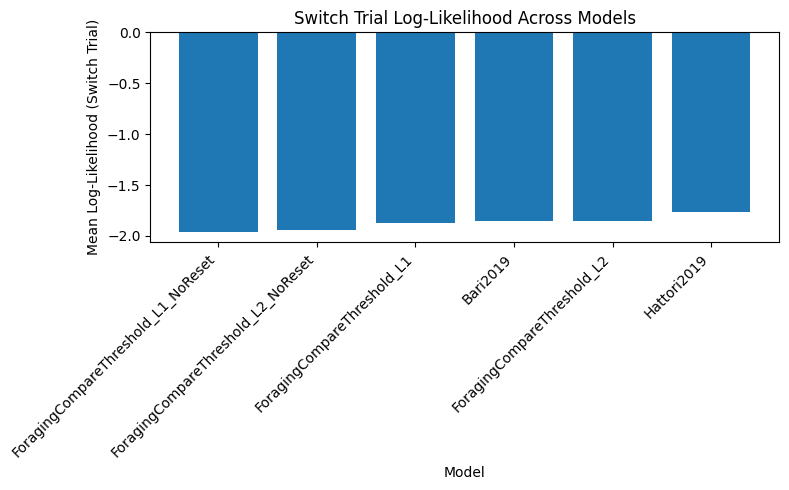

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load file from accessible path
csv_path = Path("/root/capsule/scratch/model_comparison/switch_loglik_summary_by_model.csv")
df = pd.read_csv(csv_path)

# Sort by ll_switch for clearer visualization
df = df.sort_values("ll_switch")

# Create single bar plot of switch-trial log-likelihood
plt.figure(figsize=(8, 5))
plt.bar(df["model_name"], df["ll_switch"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Log-Likelihood (Switch Trial)")
plt.xlabel("Model")
plt.title("Switch Trial Log-Likelihood Across Models")
plt.tight_layout()
plt.show()

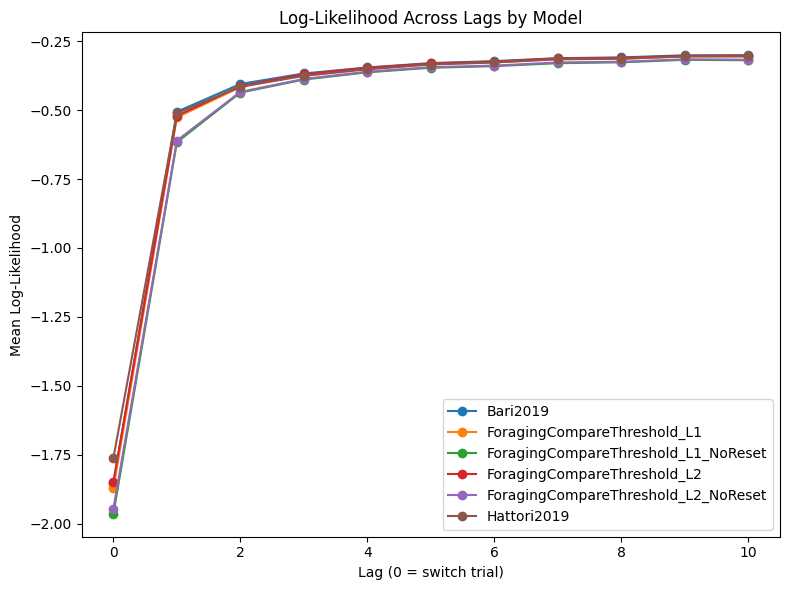

,model_name,ll_switch,ll_after_1,ll_after_2,ll_after_3,ll_after_4,ll_after_5,ll_after_6,ll_after_7,ll_after_8,ll_after_9,ll_after_10
0,Bari2019,-1.851908,-0.505529,-0.404841,-0.366663,-0.344910,-0.328971,-0.321861,-0.311133,-0.308402,-0.300652,-0.300575
1,ForagingCompareThreshold_L1,-1.871588,-0.525949,-0.415991,-0.372604,-0.348849,-0.332794,-0.326349,-0.314893,-0.313095,-0.305000,-0.304400
2,ForagingCompareThreshold_L1_NoReset,-1.964612,-0.616386,-0.435984,-0.388791,-0.362507,-0.345971,-0.340138,-0.329346,-0.326205,-0.317113,-0.318727
3,ForagingCompareThreshold_L2,-1.849468,-0.520759,-0.412299,-0.369243,-0.345906,-0.330422,-0.323696,-0.312057,-0.310101,-0.302783,-0.301920
4,ForagingCompareThreshold_L2_NoReset,-1.946107,-0.610215,-0.433412,-0.386666,-0.360331,-0.343803,-0.337991,-0.326664,-0.324137,-0.315297,-0.316569
5,Hattori2019,-1.761668,-0.510566,-0.414549,-0.375604,-0.351587,-0.334179,-0.326831,-0.315060,-0.313474,-0.304710,-0.304498


In [44]:
# Load and visualize per-session summary across lags for each model
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Try reading from /mnt/data first (recommended accessible location)
csv_path = Path("/root/capsule/scratch/model_comparison/switch_loglik_summary_by_model.csv")

if not csv_path.exists():
    raise FileNotFoundError(
        "File not accessible. Please copy switch_loglik_summary.csv to /mnt/data/ first."
    )

df = pd.read_csv(csv_path)

# Identify lag columns (ll_switch, ll_after_1, ll_after_2, ...)
lag_cols = [c for c in df.columns if c == "ll_switch" or c.startswith("ll_after_")]
lag_cols = sorted(
    lag_cols,
    key=lambda x: 0 if x == "ll_switch" else int(x.split("_")[-1])
)

# Aggregate across sessions per model (mean across sessions)
df_model = (
    df.groupby("model_name")[lag_cols]
    .mean()
    .reset_index()
)

# X-axis values: 0 for switch trial, 1..N for after lags
x_vals = []
for col in lag_cols:
    if col == "ll_switch":
        x_vals.append(0)
    else:
        x_vals.append(int(col.split("_")[-1]))

# Plot all models in ONE figure
plt.figure(figsize=(8, 6))

for _, row in df_model.iterrows():
    y_vals = row[lag_cols].values.astype(float)
    plt.plot(x_vals, y_vals, marker="o", label=row["model_name"])

plt.xlabel("Lag (0 = switch trial)")
plt.ylabel("Mean Log-Likelihood")
plt.title("Log-Likelihood Across Lags by Model")
plt.legend()
plt.tight_layout()
plt.show()

df_model


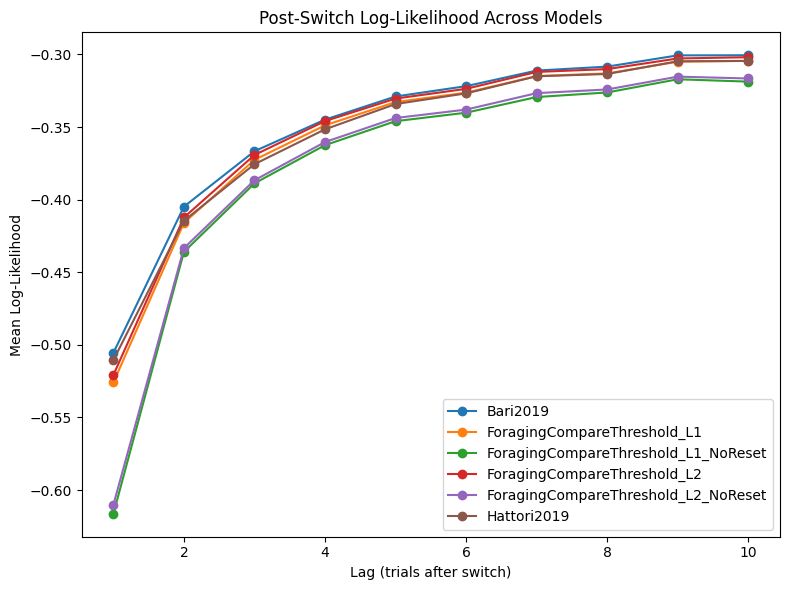

,model_name,ll_after_1,ll_after_2,ll_after_3,ll_after_4,ll_after_5,ll_after_6,ll_after_7,ll_after_8,ll_after_9,ll_after_10
0,Bari2019,-0.505529,-0.404841,-0.366663,-0.344910,-0.328971,-0.321861,-0.311133,-0.308402,-0.300652,-0.300575
1,ForagingCompareThreshold_L1,-0.525949,-0.415991,-0.372604,-0.348849,-0.332794,-0.326349,-0.314893,-0.313095,-0.305000,-0.304400
2,ForagingCompareThreshold_L1_NoReset,-0.616386,-0.435984,-0.388791,-0.362507,-0.345971,-0.340138,-0.329346,-0.326205,-0.317113,-0.318727
3,ForagingCompareThreshold_L2,-0.520759,-0.412299,-0.369243,-0.345906,-0.330422,-0.323696,-0.312057,-0.310101,-0.302783,-0.301920
4,ForagingCompareThreshold_L2_NoReset,-0.610215,-0.433412,-0.386666,-0.360331,-0.343803,-0.337991,-0.326664,-0.324137,-0.315297,-0.316569
5,Hattori2019,-0.510566,-0.414549,-0.375604,-0.351587,-0.334179,-0.326831,-0.315060,-0.313474,-0.304710,-0.304498


In [45]:
# Load and visualize per-session summary across lags for each model
# (excluding lag 0 / switch trial)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

csv_path = Path("/root/capsule/scratch/model_comparison/switch_loglik_summary_by_model.csv")

if not csv_path.exists():
    raise FileNotFoundError(
        "Please copy switch_loglik_summary.csv to /mnt/data/ first."
    )

df = pd.read_csv(csv_path)

# Identify only post-switch lag columns (exclude ll_switch)
lag_cols = [c for c in df.columns if c.startswith("ll_after_")]

# Sort by lag number
lag_cols = sorted(lag_cols, key=lambda x: int(x.split("_")[-1]))

# Aggregate across sessions per model (mean across sessions)
df_model = (
    df.groupby("model_name")[lag_cols]
    .mean()
    .reset_index()
)

# X-axis: 1..N
x_vals = [int(col.split("_")[-1]) for col in lag_cols]

# Plot all models in ONE figure
plt.figure(figsize=(8, 6))

for _, row in df_model.iterrows():
    y_vals = row[lag_cols].values.astype(float)
    plt.plot(x_vals, y_vals, marker="o", label=row["model_name"])

plt.xlabel("Lag (trials after switch)")
plt.ylabel("Mean Log-Likelihood")
plt.title("Post-Switch Log-Likelihood Across Models")
plt.legend()
plt.tight_layout()
plt.show()

df_model
